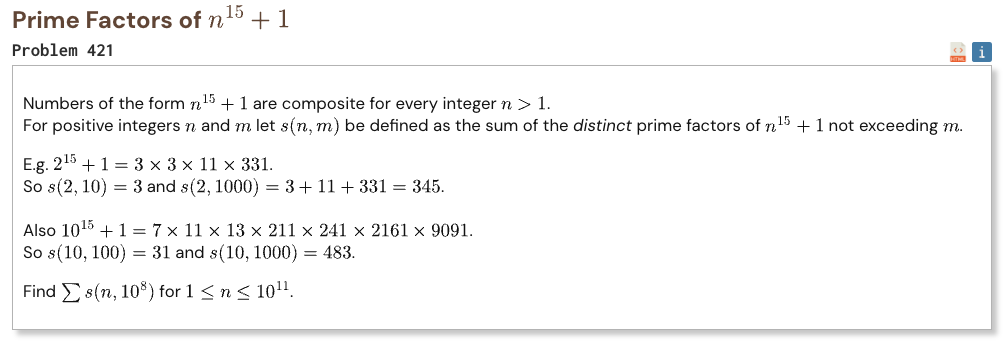

## Initial approach

-   switch the summation so we loop over primes up to one hundred million instead of all values of n
-   for each prime count how many values of n make that prime divide the target number
-   these valid values repeat every prime steps so most of the count comes from complete blocks
-   the valid remainders are the negatives of the fifteenth roots of one modulo that prime
-   there are only one three five or fifteen such roots depending on the prime
-   find a small element that generates these roots and produce the whole root set from it
-   use a sieve to generate all required primes and add each prime multiplied by its number of appearances

In [1]:
from math import gcd, isqrt


def primes_up_to(limit):
    sieve = bytearray(b"\x01") * (limit // 2 + 1)

    for p in range(3, isqrt(limit) + 1, 2):
        if sieve[p // 2]:
            start = p * p // 2
            count = (len(sieve) - 1 - start) // p + 1
            sieve[start::p] = b"\x00" * count

    yield 2

    for i in range(1, len(sieve)):
        p = 2 * i + 1

        if p > limit:
            break

        if sieve[i]:
            yield p


def subgroup_generator(p, d):
    if d == 1:
        return 1

    a = 2

    while True:
        h = pow(a, (p - 1) // d, p)

        if h != 1:
            valid = True

            if d % 3 == 0 and pow(h, d // 3, p) == 1:
                valid = False

            if d % 5 == 0 and pow(h, d // 5, p) == 1:
                valid = False

            if valid:
                return h

        a += 1


def roots_of_target(p):
    d = gcd(15, p - 1)

    if d == 1:
        return [p - 1]

    h = subgroup_generator(p, d)

    roots = []
    value = 1

    for _ in range(d):
        roots.append((-value) % p)
        value = value * h % p

    return roots


def solve(n_limit, prime_limit):
    result = 0

    for p in primes_up_to(prime_limit):
        d = gcd(15, p - 1)

        full_blocks = n_limit // p
        remainder = n_limit % p

        count = full_blocks * d

        if d == 1:
            if p - 1 <= remainder:
                count += 1
        else:
            for root in roots_of_target(p):
                if 1 <= root <= remainder:
                    count += 1

        result += p * count

    return result

In [2]:
%%time
result = solve(10**11, 10**8)
print("Result:", result)

Result: 2304215802083466198
CPU times: user 11.1 s, sys: 82.3 ms, total: 11.2 s
Wall time: 11.3 s
